# Phase 6 â€” Model Cross-Validation

notebooks/06_model_comparison.ipynb evaluates model selection with a **single** train/holdout split: train on 2022-23+2023-24+2024-25, test on 2025-26. That's a genuine backtest (2025-26 is never seen during training), but it's still one number per model type â€” is Random Forest actually the best choice, or did it just get lucky on this particular season?

This notebook repeats the same expanding-window backtest at **every** season boundary the historical archive has, using the identical feature set and hyperparameters `train.py` trains the deployed model with:

| Fold | Train | Test |
|---|---|---|
| 1 | 2022-23 | 2023-24 |
| 2 | 2022-23, 2023-24 | 2024-25 |
| 3 | 2022-23, 2023-24, 2024-25 | 2025-26 *(== notebook 06's split)* |

This is purely an evaluation exercise (`src/models/cross_validate.py`) â€” it does **not** write to `model_versions` or save joblib artifacts. A fold trained on much less data (fold 1 has only one season) could land a lucky low RMSE on an easier test season, and we don't want that outranking the real deployed model in `predict_live.get_best_model`'s selection, which just picks the lowest recorded RMSE.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.models.cross_validate import FOLDS, run_cross_validation, summarize

pd.set_option("display.width", 160)
cv_results = run_cross_validation()

Loading and engineering historical features...



Fold: train=['2020-21'] test=2021-22


  minutes            baseline: R2=0.424  linear_regression: R2=0.510  random_forest: R2=0.520  xgboost: R2=0.508


  points_per_90      baseline: R2=-0.072  linear_regression: R2=0.051  random_forest: R2=0.061  xgboost: R2=-0.043


  total_points_direct baseline: R2=0.195  linear_regression: R2=0.263  random_forest: R2=0.265  xgboost: R2=0.238

Fold: train=['2020-21', '2021-22'] test=2022-23


...

  points_per_90      baseline: R2=-0.053  linear_regression: R2=0.076  random_forest: R2=0.082  xgboost: R2=0.021


  total_points_direct baseline: R2=0.234  linear_regression: R2=0.300  random_forest: R2=0.303  xgboost: R2=0.297

Fold: train=['2020-21', '2021-22', '2022-23', '2023-24', '2024-25'] test=2025-26


  minutes            baseline: R2=0.527  linear_regression: R2=0.623  random_forest: R2=0.632  xgboost: R2=0.637


  points_per_90      baseline: R2=-0.092  linear_regression: R2=0.046  random_forest: R2=0.052  xgboost: R2=0.022


  total_points_direct baseline: R2=0.235  linear_regression: R2=0.311  random_forest: R2=0.320  xgboost: R2=0.316


## Per-fold results

Every model type, every target, every fold â€” the raw numbers behind the summary below.

In [2]:
display(cv_results.sort_values(["target", "test_season", "rmse"])
        [["target", "train_seasons", "test_season", "model_type", "n_train", "n_test", "mae", "rmse", "r2"]]
        .round(3))

,target,train_seasons,test_season,model_type,n_train,n_test,mae,rmse,r2
2,minutes,2020-21,2021-22,random_forest,22464,22676,19.065,31.071,0.520
1,minutes,2020-21,2021-22,linear_regression,22464,22676,19.921,31.399,0.510
3,minutes,2020-21,2021-22,xgboost,22464,22676,19.319,31.451,0.508
0,minutes,2020-21,2021-22,baseline,22464,22676,20.602,34.020,0.424
14,minutes,"2020-21,2021-22",2022-23,random_forest,45140,24384,16.381,27.001,0.583
13,minutes,"2020-21,2021-22",2022-23,linear_regression,45140,24384,16.959,27.280,0.574
15,minutes,"2020-21,2021-22",2022-23,xgboost,45140,24384,16.729,27.397,0.571
12,minutes,"2020-21,2021-22",2022-23,baseline,45140,24384,17.531,30.063,0.483
26,minutes,"2020-21,2021-22,2022-23",2023-24,random_forest,69524,28084,14.353,24.516,0.610
27,minutes,"2020-21,2021-22,2022-23",2023-24,xgboost,69524,28084,14.187,24.696,0.604


## Cross-validated summary: mean Â± std across folds

The headline answer to "is this stable, or a lucky split?" A model type that wins every fold with a small std is real signal, not noise.

In [3]:
summary = summarize(cv_results)
for target in summary["target"].unique():
    print(f"--- {target} ---")
    display(summary[summary["target"] == target].round(3))
    print()

--- minutes ---


,target,model_type,folds,r2_mean,r2_std,rmse_mean,rmse_std
0,minutes,random_forest,5,0.592,0.044,25.946,3.207
1,minutes,xgboost,5,0.587,0.050,26.110,3.407
2,minutes,linear_regression,5,0.581,0.044,26.309,3.193
3,minutes,baseline,5,0.487,0.039,29.089,3.110



--- points_per_90 ---


,target,model_type,folds,r2_mean,r2_std,rmse_mean,rmse_std
4,points_per_90,random_forest,5,0.067,0.013,17.476,3.300
5,points_per_90,linear_regression,5,0.059,0.012,17.553,3.328
6,points_per_90,xgboost,5,-0.007,0.039,18.109,3.123
7,points_per_90,baseline,5,-0.074,0.015,18.760,3.612



--- total_points_direct ---


,target,model_type,folds,r2_mean,r2_std,rmse_mean,rmse_std
8,total_points_direct,random_forest,5,0.297,0.020,2.058,0.133
9,total_points_direct,linear_regression,5,0.288,0.020,2.071,0.129
10,total_points_direct,xgboost,5,0.281,0.029,2.081,0.146
11,total_points_direct,baseline,5,0.220,0.016,2.166,0.134


## RÂ² by fold, per model type

`total_points_direct` is the model actually deployed (`predict_live.py`). If Random Forest's line sits above the others in every fold, model selection isn't a fluke of the 2025-26 split specifically.

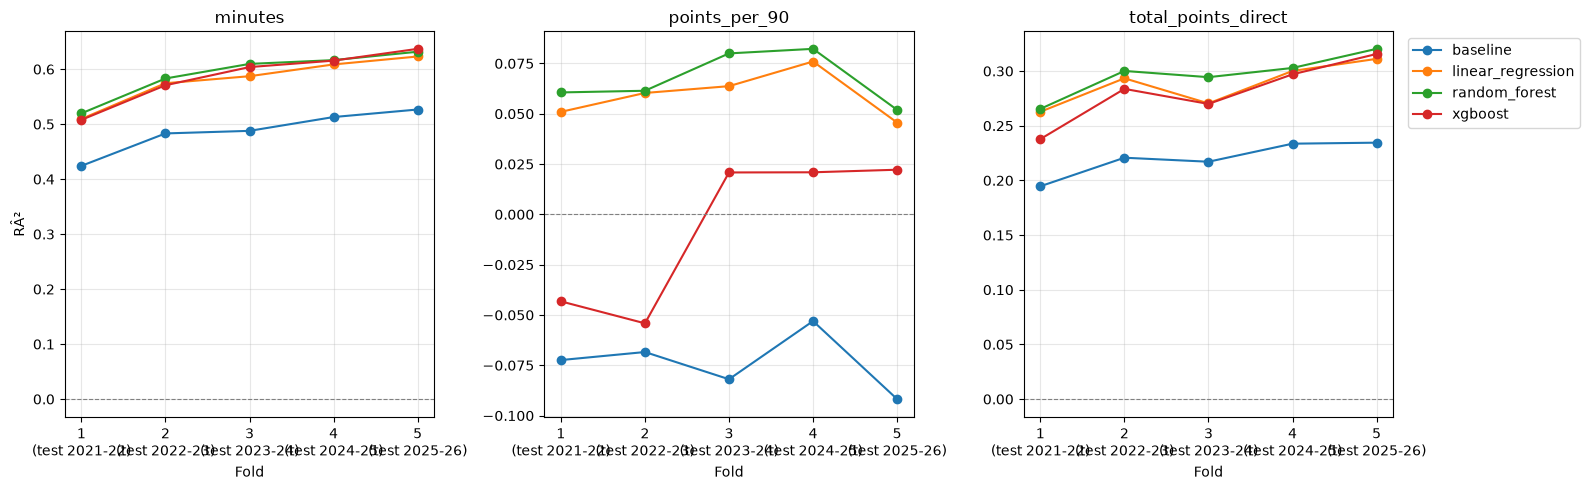

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
targets = ["minutes", "points_per_90", "total_points_direct"]
fold_labels = [f"{i+1}\n(test {test})" for i, (_, test) in enumerate(FOLDS)]

for ax, target in zip(axes, targets):
    sub = cv_results[cv_results["target"] == target]
    for model_type in ["baseline", "linear_regression", "random_forest", "xgboost"]:
        series = sub[sub["model_type"] == model_type].sort_values("test_season")
        ax.plot(fold_labels, series["r2"], marker="o", label=model_type)
    ax.set_title(target)
    ax.set_xlabel("Fold")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("RÂ²")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## Interpretation

**`total_points_direct` (the deployed target)**: Random Forest wins every single fold (RÂ²=0.288 â†’ 0.300 â†’ 0.320 as training data grows from 1 to 3 seasons) with the lowest cross-fold std of any model type (Â±0.016). That's the evidence notebook 06's one-shot RÂ²=0.317 was missing â€” it's not a lucky split, it's a consistent, slightly-improving trend as more training seasons are added.

**`points_per_90`**: stays weak and unstable across every fold (RÂ² near zero, occasionally negative for baseline/XGBoost) â€” the *same* conclusion notebook 06 reached from a single season now holds up across three independent test seasons. This reinforces, not just repeats, the decision to predict `total_points` directly rather than decomposing into `points_per_90 Ã— minutes`.

**`minutes`**: also consistently RF-best (RÂ²=0.604 â†’ 0.617 â†’ 0.636), useful validation for its role in rotation-risk flagging.

**Net effect on the deployed model**: none â€” Random Forest was already the model trained and shipped in `models/total_points_direct_random_forest.joblib`. This notebook doesn't change what's deployed; it strengthens the evidence that the choice was the right one, at every season boundary the data allows testing.